In [4]:
%pip install kaggle


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import random
from pathlib import Path
from PIL import Image

In [6]:

# --- CONFIGURATION ---
import requests, zipfile, io, os

DATA_DIR = "./vehicle_classification/Vehicles/"

if not os.path.exists(DATA_DIR):
    print("Downloading dataset...")
    url = "https://www.kaggle.com/api/v1/datasets/download/mohamedmaher5/vehicle-classification"
    response = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(response.content))
    z.extractall("vehicle_classification")
    print("Done.")

IMG_SIZE = (224, 224)       # common size; you can reduce to speed up
BATCH_SIZE = 16
EPOCHS = 5               # change as needed

# --- 1. Load dataset paths and labels ---
classes = sorted([d.name for d in os.scandir(DATA_DIR) if d.is_dir()])
print("Classes:", classes)

image_paths = []
image_labels = []

for idx, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(os.path.join(cls_dir, fname))
            image_labels.append(idx)

print("Total images:", len(image_paths))

Classes: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']
Total images: 5587


In [7]:
# --- 2. Split train / validation ---
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, image_labels, test_size=0.2, stratify=image_labels, random_state=42
)

print("Train images:", len(train_paths), "Validation images:", len(val_paths))

Train images: 4469 Validation images: 1118


In [8]:
# --- 3. Define data loading + preprocessing function ---
def load_and_preprocess(path, label):
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    arr = np.array(img) / 255.0           # normalize to [0,1]
    return arr, label

def data_generator(paths, labels, batch_size, shuffle=True):
    idxs = list(range(len(paths)))
    while True:
        if shuffle:
            random.shuffle(idxs)
        for start in range(0, len(paths), batch_size):
            batch_idx = idxs[start:start+batch_size]
            batch_images = []
            batch_labels = []
            for i in batch_idx:
                img, lab = load_and_preprocess(paths[i], labels[i])
                batch_images.append(img)
                batch_labels.append(lab)
            yield np.stack(batch_images, axis=0), np.array(batch_labels)



In [9]:
# --- 4. Build a simple CNN model (or use transfer learning) ---
num_classes = len(classes)

base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze base

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# --- 5. Prepare generators and train ---
train_gen = data_generator(train_paths, train_labels, BATCH_SIZE, shuffle=True)
val_gen = data_generator(val_paths, val_labels, BATCH_SIZE, shuffle=False)

steps_per_epoch = len(train_paths) // BATCH_SIZE
val_steps = len(val_paths) // BATCH_SIZE

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_gen,
    validation_steps=val_steps
)



Epoch 1/5
 39/279 ━━━━━━━━━━━━━━━━━━━━ 2:27 613ms/step - accuracy: 0.2737 - loss: 2.0885

c:\Users\Erika Alvarez\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


104/279 ━━━━━━━━━━━━━━━━━━━━ 1:32 527ms/step - accuracy: 0.4135 - loss: 1.6799

KeyboardInterrupt: 

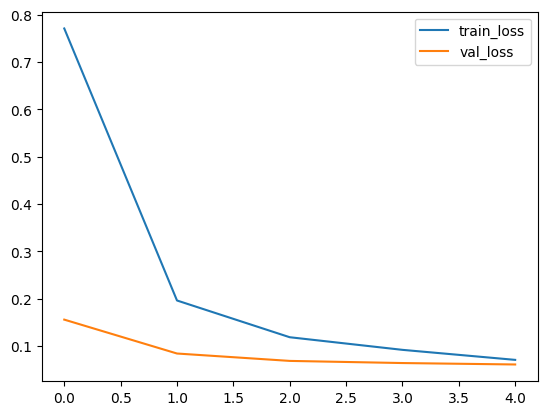

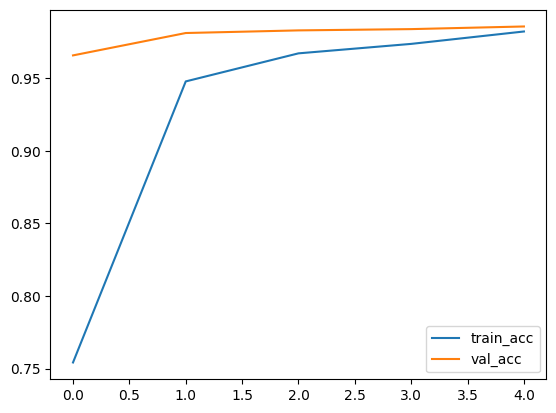

In [ ]:
# --- 6. Evaluate and optionally test some samples ---
# Plot training curves
plt.plot(history.history['loss'], label="train_loss")
plt.plot(history.history['val_loss'], label="val_loss")
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label="train_acc")
plt.plot(history.history['val_accuracy'], label="val_acc")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
GT: Bikes → Pred: Bikes


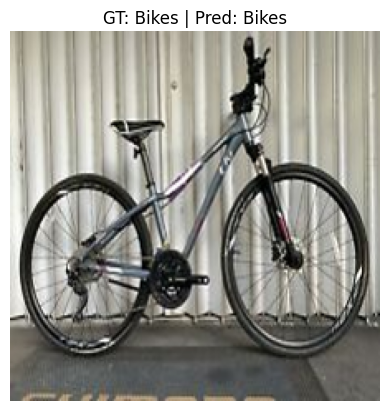

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
GT: Trains → Pred: Trains


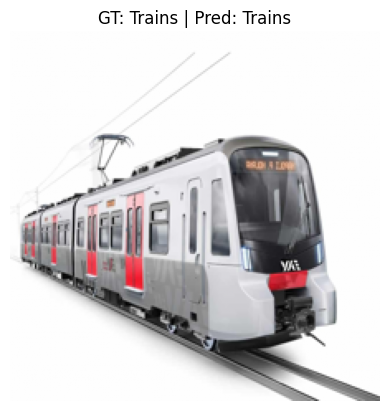

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
GT: Cars → Pred: Cars


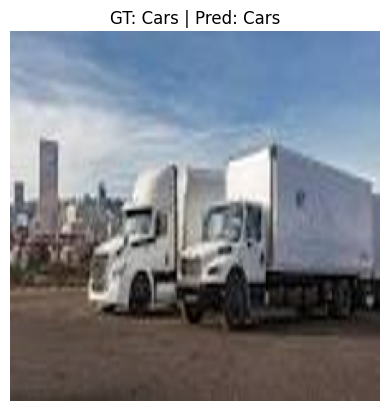

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
GT: Trains → Pred: Trains


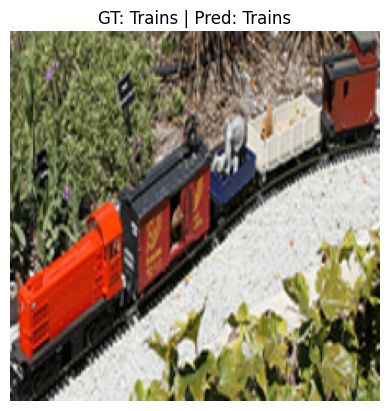

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
GT: Auto Rickshaws → Pred: Auto Rickshaws


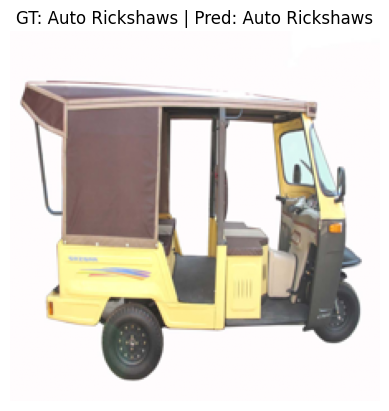

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
GT: Bikes → Pred: Bikes


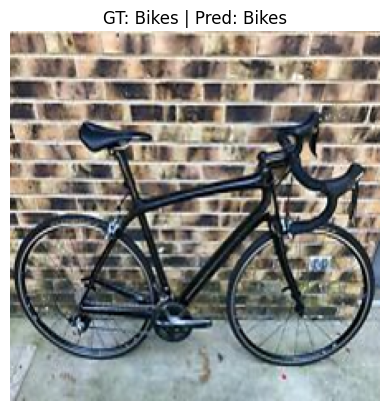

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
GT: Bikes → Pred: Bikes


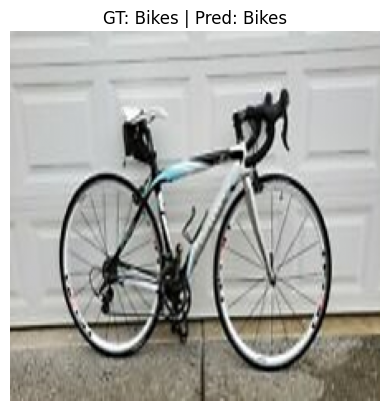

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
GT: Ships → Pred: Ships


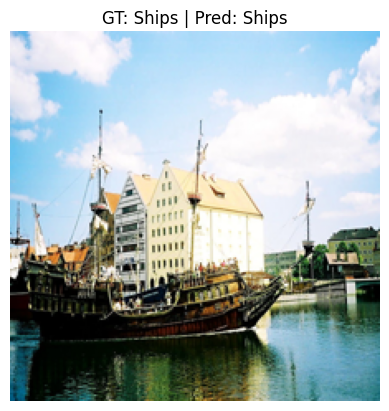

In [ ]:
# --- 7. Visualize some predictions vs ground truth ---
import random
n_show = 8
sel = random.sample(range(len(val_paths)), n_show)
for idx in sel:
    img, lab = load_and_preprocess(val_paths[idx], val_labels[idx])
    img_input = np.expand_dims(img, 0)
    preds = model.predict(img_input)
    pred_idx = np.argmax(preds[0])
    print("GT:", classes[lab], "→ Pred:", classes[pred_idx])
    plt.imshow(img)
    plt.title(f"GT: {classes[lab]} | Pred: {classes[pred_idx]}")
    plt.axis("off")
    plt.show()

In [16]:
import grpc
import dashboard_pb2, dashboard_pb2_grpc

channel = grpc.insecure_channel("localhost:50051")
stub = dashboard_pb2_grpc.DashboardStub(channel)

def send_test_batch():
    batch = dashboard_pb2.BatchUpdate()
    batch.index = 1

    # Fake image
    img = batch.images.add()
    img.image = b"\x89PNGTEST"   # fake bytes
    img.width = 64
    img.height = 64

    # Fake labels
    batch.predictions.append("cat")
    batch.groundTruths.append("cat")

    reply = stub.SendBatchUpdate(batch)
    print("Batch reply:", reply.status, reply.message)

send_test_batch()


Batch reply: True Batch received
